In [1]:
import pandas as pd
df = pd.read_csv('/content/spam mail.csv')
print(df)

     Category                                           Masseges
0         ham  Go until jurong point, crazy.. Available only ...
1         ham                      Ok lar... Joking wif u oni...
2        spam  Free entry in 2 a wkly comp to win FA Cup fina...
3         ham  U dun say so early hor... U c already then say...
4         ham  Nah I don't think he goes to usf, he lives aro...
...       ...                                                ...
5567     spam  This is the 2nd time we have tried 2 contact u...
5568      ham              Will Ì_ b going to esplanade fr home?
5569      ham  Pity, * was in mood for that. So...any other s...
5570      ham  The guy did some bitching but I acted like i'd...
5571      ham                         Rofl. Its true to its name

[5572 rows x 2 columns]


In [2]:
# First five rows
print(df.head())

  Category                                           Masseges
0      ham  Go until jurong point, crazy.. Available only ...
1      ham                      Ok lar... Joking wif u oni...
2     spam  Free entry in 2 a wkly comp to win FA Cup fina...
3      ham  U dun say so early hor... U c already then say...
4      ham  Nah I don't think he goes to usf, he lives aro...


In [3]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  5572 non-null   object
 1   Masseges  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB
None


In [4]:
print(df.dropna(inplace = True))

None


In [5]:
print(df.fillna(df,inplace = True))

None


In [6]:
# input and output
X = df['Masseges'] # Input
y = df['Category'] # output

In [20]:
# TF-IDF Vectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer()
x = vectorizer.fit_transform(X)

In [8]:
# train test split
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2,random_state = 42)

In [32]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(x_train,y_train)

LogisticRegression()

In [33]:
# Accuracy score
from sklearn.metrics import accuracy_score
y_pred = model.predict(x_test)
accuracy = accuracy_score(y_test,y_pred)
print(accuracy)

0.9632286995515695


In [34]:
from sklearn.metrics import precision_score, recall_score, f1_score
print(precision_score(y_test,y_pred, pos_label='spam'))
print(f1_score(y_test,y_pred, pos_label='spam'))
print(recall_score(y_test,y_pred, pos_label='spam'))

1.0
0.8416988416988417
0.7266666666666667


In [35]:
# Decision tree
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier()
model.fit(x_train,y_train)

DecisionTreeClassifier()

In [36]:
# Accuracy score
from sklearn.metrics import accuracy_score
y_pred = model.predict(x_test)
accuracy = accuracy_score(y_test,y_pred)
print(accuracy)

0.9704035874439462


In [37]:
from sklearn.metrics import precision_score, recall_score, f1_score
print(precision_score(y_test,y_pred, pos_label='spam'))
print(f1_score(y_test,y_pred, pos_label='spam'))
print(recall_score(y_test,y_pred, pos_label='spam'))

0.903448275862069
0.888135593220339
0.8733333333333333


In [42]:
# KNN
from sklearn.neighbors import KNeighborsClassifier
model = KNeighborsClassifier()
model.fit(x_train,y_train)

KNeighborsClassifier()

In [43]:
# Accuracy score
from sklearn.metrics import accuracy_score
y_pred = model.predict(x_test)
accuracy = accuracy_score(y_test,y_pred)
print(accuracy)

0.9130044843049328


In [44]:
from sklearn.metrics import precision_score, recall_score, f1_score
print(precision_score(y_test,y_pred, pos_label='spam'))
print(f1_score(y_test,y_pred, pos_label='spam'))
print(recall_score(y_test,y_pred, pos_label='spam'))

1.0
0.5221674876847291
0.35333333333333333


In [48]:
# Random Forest
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier()
model.fit(x_train,y_train)

RandomForestClassifier()

In [49]:
# Accuracy score
from sklearn.metrics import accuracy_score
y_pred = model.predict(x_test)
accuracy = accuracy_score(y_test,y_pred)
print(accuracy)

0.9766816143497757


In [50]:
from sklearn.metrics import precision_score, recall_score, f1_score
print(precision_score(y_test,y_pred, pos_label='spam'))
print(f1_score(y_test,y_pred, pos_label='spam'))
print(recall_score(y_test,y_pred, pos_label='spam'))

1.0
0.9051094890510949
0.8266666666666667


In [51]:
# Naive Bayes (text classification)
from sklearn.naive_bayes import MultinomialNB
model = MultinomialNB()
model.fit(x_train.toarray(),y_train)

MultinomialNB()

In [52]:
# Accuracy score
from sklearn.metrics import accuracy_score
y_pred = model.predict(x_test.toarray())
accuracy = accuracy_score(y_test,y_pred)
print(accuracy)

0.9623318385650225


In [53]:
from sklearn.metrics import precision_score, recall_score, f1_score
print(precision_score(y_test,y_pred, pos_label='spam'))
print(f1_score(y_test,y_pred, pos_label='spam'))
print(recall_score(y_test,y_pred, pos_label='spam'))

1.0
0.8372093023255814
0.72


In [55]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test,y_pred))

[[965   0]
 [ 42 108]]


In [57]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

         ham       0.96      1.00      0.98       965
        spam       1.00      0.72      0.84       150

    accuracy                           0.96      1115
   macro avg       0.98      0.86      0.91      1115
weighted avg       0.96      0.96      0.96      1115



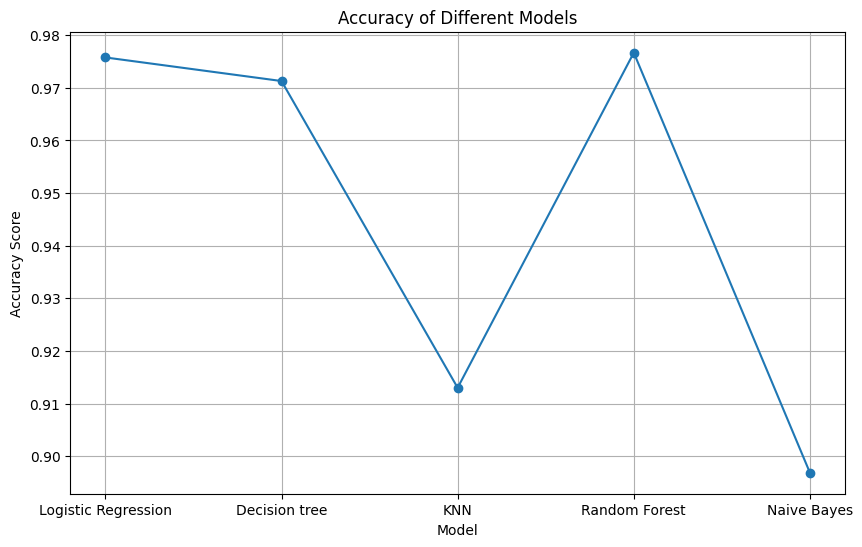

In [58]:
import matplotlib.pyplot as plt


X_models = ['Logistic Regression','Decision tree','KNN','Random Forest','Naive Bayes']
y_accuracy = [0.9757847533632287, 0.9713004484304932, 0.9130044843049328, 0.9766816143497757, 0.8968609865470852]

plt.figure(figsize = (10,6))
plt.plot(X_models, y_accuracy,marker='o')
plt.xlabel('Model')
plt.ylabel('Accuracy Score')
plt.title('Accuracy of Different Models')
plt.grid(True)
plt.show()

In [65]:
while True:
    msg = input("\nEnter Email/SMS (or type 'exit'): ")

    if msg.lower() == "exit":
        break

    # Transform the input message using the previously fitted vectorizer
    transformed_msg = vectorizer.transform([msg])

    # Predict using the transformed message
    prediction = model.predict(transformed_msg)[0]

    if prediction == "spam":
        print("🚨 Spam Message")
    else:
        print("✅ Not Spam")


Enter Email/SMS (or type 'exit'): hello
✅ Not Spam

Enter Email/SMS (or type 'exit'): exit


In [75]:
import pickle

pickle.dump(model, open("spam_model.pkl", "wb"))